In [18]:
from pathlib import Path
import xarray as xr
import pandas as pd

data_dir = Path(r"D:\INCOIS\Data_Float_Fixed")
phyto_list = []



In [19]:
files = sorted(data_dir.glob("*.nc"))

for i, file in enumerate(files):

    ds = xr.open_dataset(file)

    gujarat = ds.sel(
        lat=slice(23,19),
        lon=slice(62,67)
    )

    phytobloom = xr.where(
        (gujarat["PhytoID"] == 1) &
        (gujarat["CHLOR_A"] > 1),

        1,

        xr.where(
            (gujarat["PhytoID"] == 2) &
            (gujarat["CHLOR_A"] > 1),

            2,

            0
        )
    ).astype("int16")

    date = pd.to_datetime(
        file.name[1:9],
        format="%Y%m%d"
    )

    phytobloom = phytobloom.expand_dims(
        time=[date]
    )

    phyto_list.append(phytobloom)

    ds.close()

    if (i+1) % 100 == 0:
        print(f"{i+1}/{len(files)}")

100/8344
200/8344
300/8344
400/8344
500/8344
600/8344
700/8344
800/8344
900/8344
1000/8344
1100/8344
1200/8344
1300/8344
1400/8344
1500/8344
1600/8344
1700/8344
1800/8344
1900/8344
2000/8344
2100/8344
2200/8344
2300/8344
2400/8344
2500/8344
2600/8344
2700/8344
2800/8344
2900/8344
3000/8344
3100/8344
3200/8344
3300/8344
3400/8344
3500/8344
3600/8344
3700/8344
3800/8344
3900/8344
4000/8344
4100/8344
4200/8344
4300/8344
4400/8344
4500/8344
4600/8344
4700/8344
4800/8344
4900/8344
5000/8344
5100/8344
5200/8344
5300/8344
5400/8344
5500/8344
5600/8344
5700/8344
5800/8344
5900/8344
6000/8344
6100/8344
6200/8344
6300/8344
6400/8344
6500/8344
6600/8344
6700/8344
6800/8344
6900/8344
7000/8344
7100/8344
7200/8344
7300/8344
7400/8344
7500/8344
7600/8344
7700/8344
7800/8344
7900/8344
8000/8344
8100/8344
8200/8344
8300/8344


In [20]:
phyto = xr.concat(
    phyto_list,
    dim="time"
)

phyto_ds = phyto.to_dataset(
    name="PHYTOBLOOM"
)

print(phyto_ds)

<xarray.Dataset> Size: 192MB
Dimensions:     (time: 8344, lon: 120, lat: 96)
Coordinates:
  * time        (time) datetime64[us] 67kB 2003-01-01 2003-01-02 ... 2025-11-30
  * lon         (lon) float32 480B 62.02 62.06 62.1 62.15 ... 66.9 66.94 66.98
  * lat         (lat) float32 384B 22.98 22.94 22.9 22.85 ... 19.1 19.06 19.02
Data variables:
    PHYTOBLOOM  (time, lat, lon) int16 192MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0


In [21]:
phyto_ds.to_netcdf(
    r"D:\INCOIS\PHYTOBLOOM_GUJARAT.nc"
)

In [1]:
import xarray as xr, numpy as np

test = xr.open_dataset(
    r"D:\INCOIS\PHYTOBLOOM_GUJARAT.nc"
)

print(
    np.unique(
        test["PHYTOBLOOM"]
        .isel(time=0)
        .values
    )
)

[0 1 2]


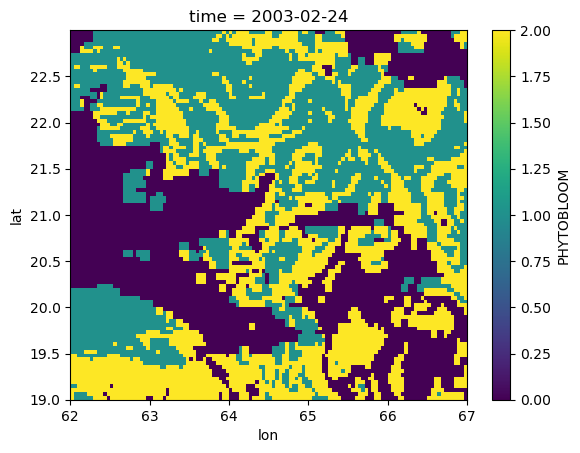

In [3]:
test["PHYTOBLOOM"].sel(time="2003-02-24").plot()

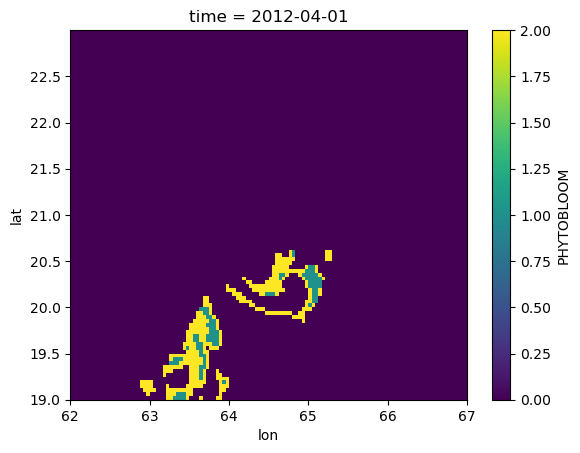

In [28]:
test["PHYTOBLOOM"].sel(time="2012-04-01").plot()

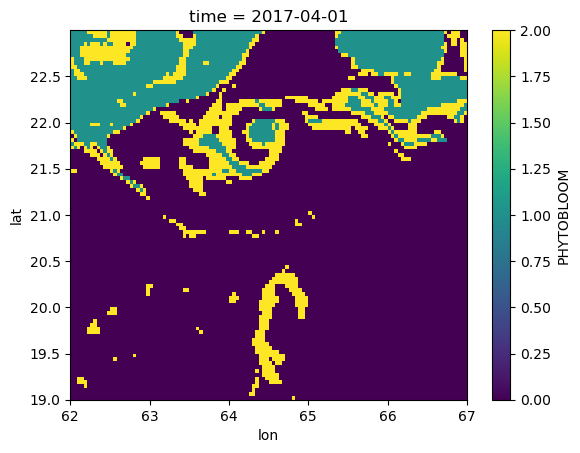

In [29]:
test["PHYTOBLOOM"].sel(time="2017-04-01").plot()

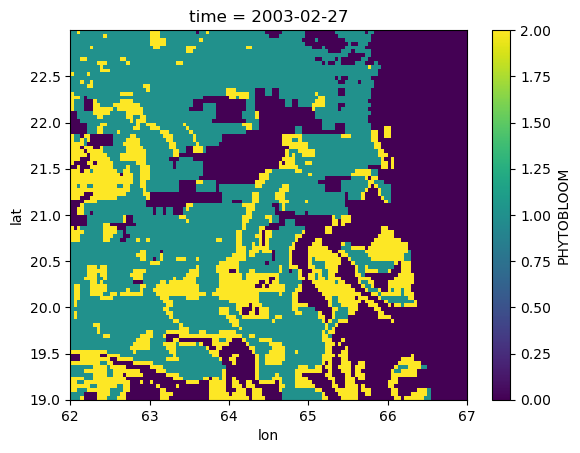

In [30]:
test["PHYTOBLOOM"].sel(time="2003-02-27").plot()

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ----------------------------
# Load dataset
# ----------------------------
ds = xr.open_dataset(r"D:\INCOIS\PHYTOBLOOM_NAS.nc")

# ----------------------------
# Seasons
# ----------------------------
season_months = {
    "YEAR": list(range(1,13)),
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJAS": [6, 7, 8, 9],
    "ON": [10, 11]
}

years = np.arange(1998, 2026)
# ----------------------------
# Compute daily bloom percentages
# ----------------------------
results = {}

for season, months in season_months.items():

    dates = []

    c1_daily = []
    c2_daily = []

    for yr in years:

        # ----------------------------
        # Select season
        # ----------------------------
        if season == "YEAR":

            mask = (ds.time.dt.year == yr)

        elif season == "DJF":

            mask = (
                ((ds.time.dt.year == yr - 1) & (ds.time.dt.month == 12)) |
                ((ds.time.dt.year == yr) & (ds.time.dt.month.isin([1, 2])))
            )

        else:

            mask = (
                (ds.time.dt.year == yr) &
                (ds.time.dt.month.isin(months))
            )

        season_ds = ds.sel(time=mask)

        if season_ds.time.size == 0:
            continue

        bloom = season_ds["PHYTOBLOOM"].values
        time = pd.to_datetime(season_ds.time.values)

        # ----------------------------
        # Daily bloom percentages
        # ----------------------------
        for img, day in zip(bloom, time):

            valid = ~np.isnan(img)

            if valid.sum() == 0:
                continue

            pct_c1 = (
                100 * np.sum(img[valid] == 1)
                / valid.sum()
            )

            pct_c2 = (
                100 * np.sum(img[valid] == 2)
                / valid.sum()
            )

            dates.append(day)

            c1_daily.append(pct_c1)
            c2_daily.append(pct_c2)

    results[season] = {
        "dates": np.array(dates),
        "c1": np.array(c1_daily),
        "c2": np.array(c2_daily)
    }

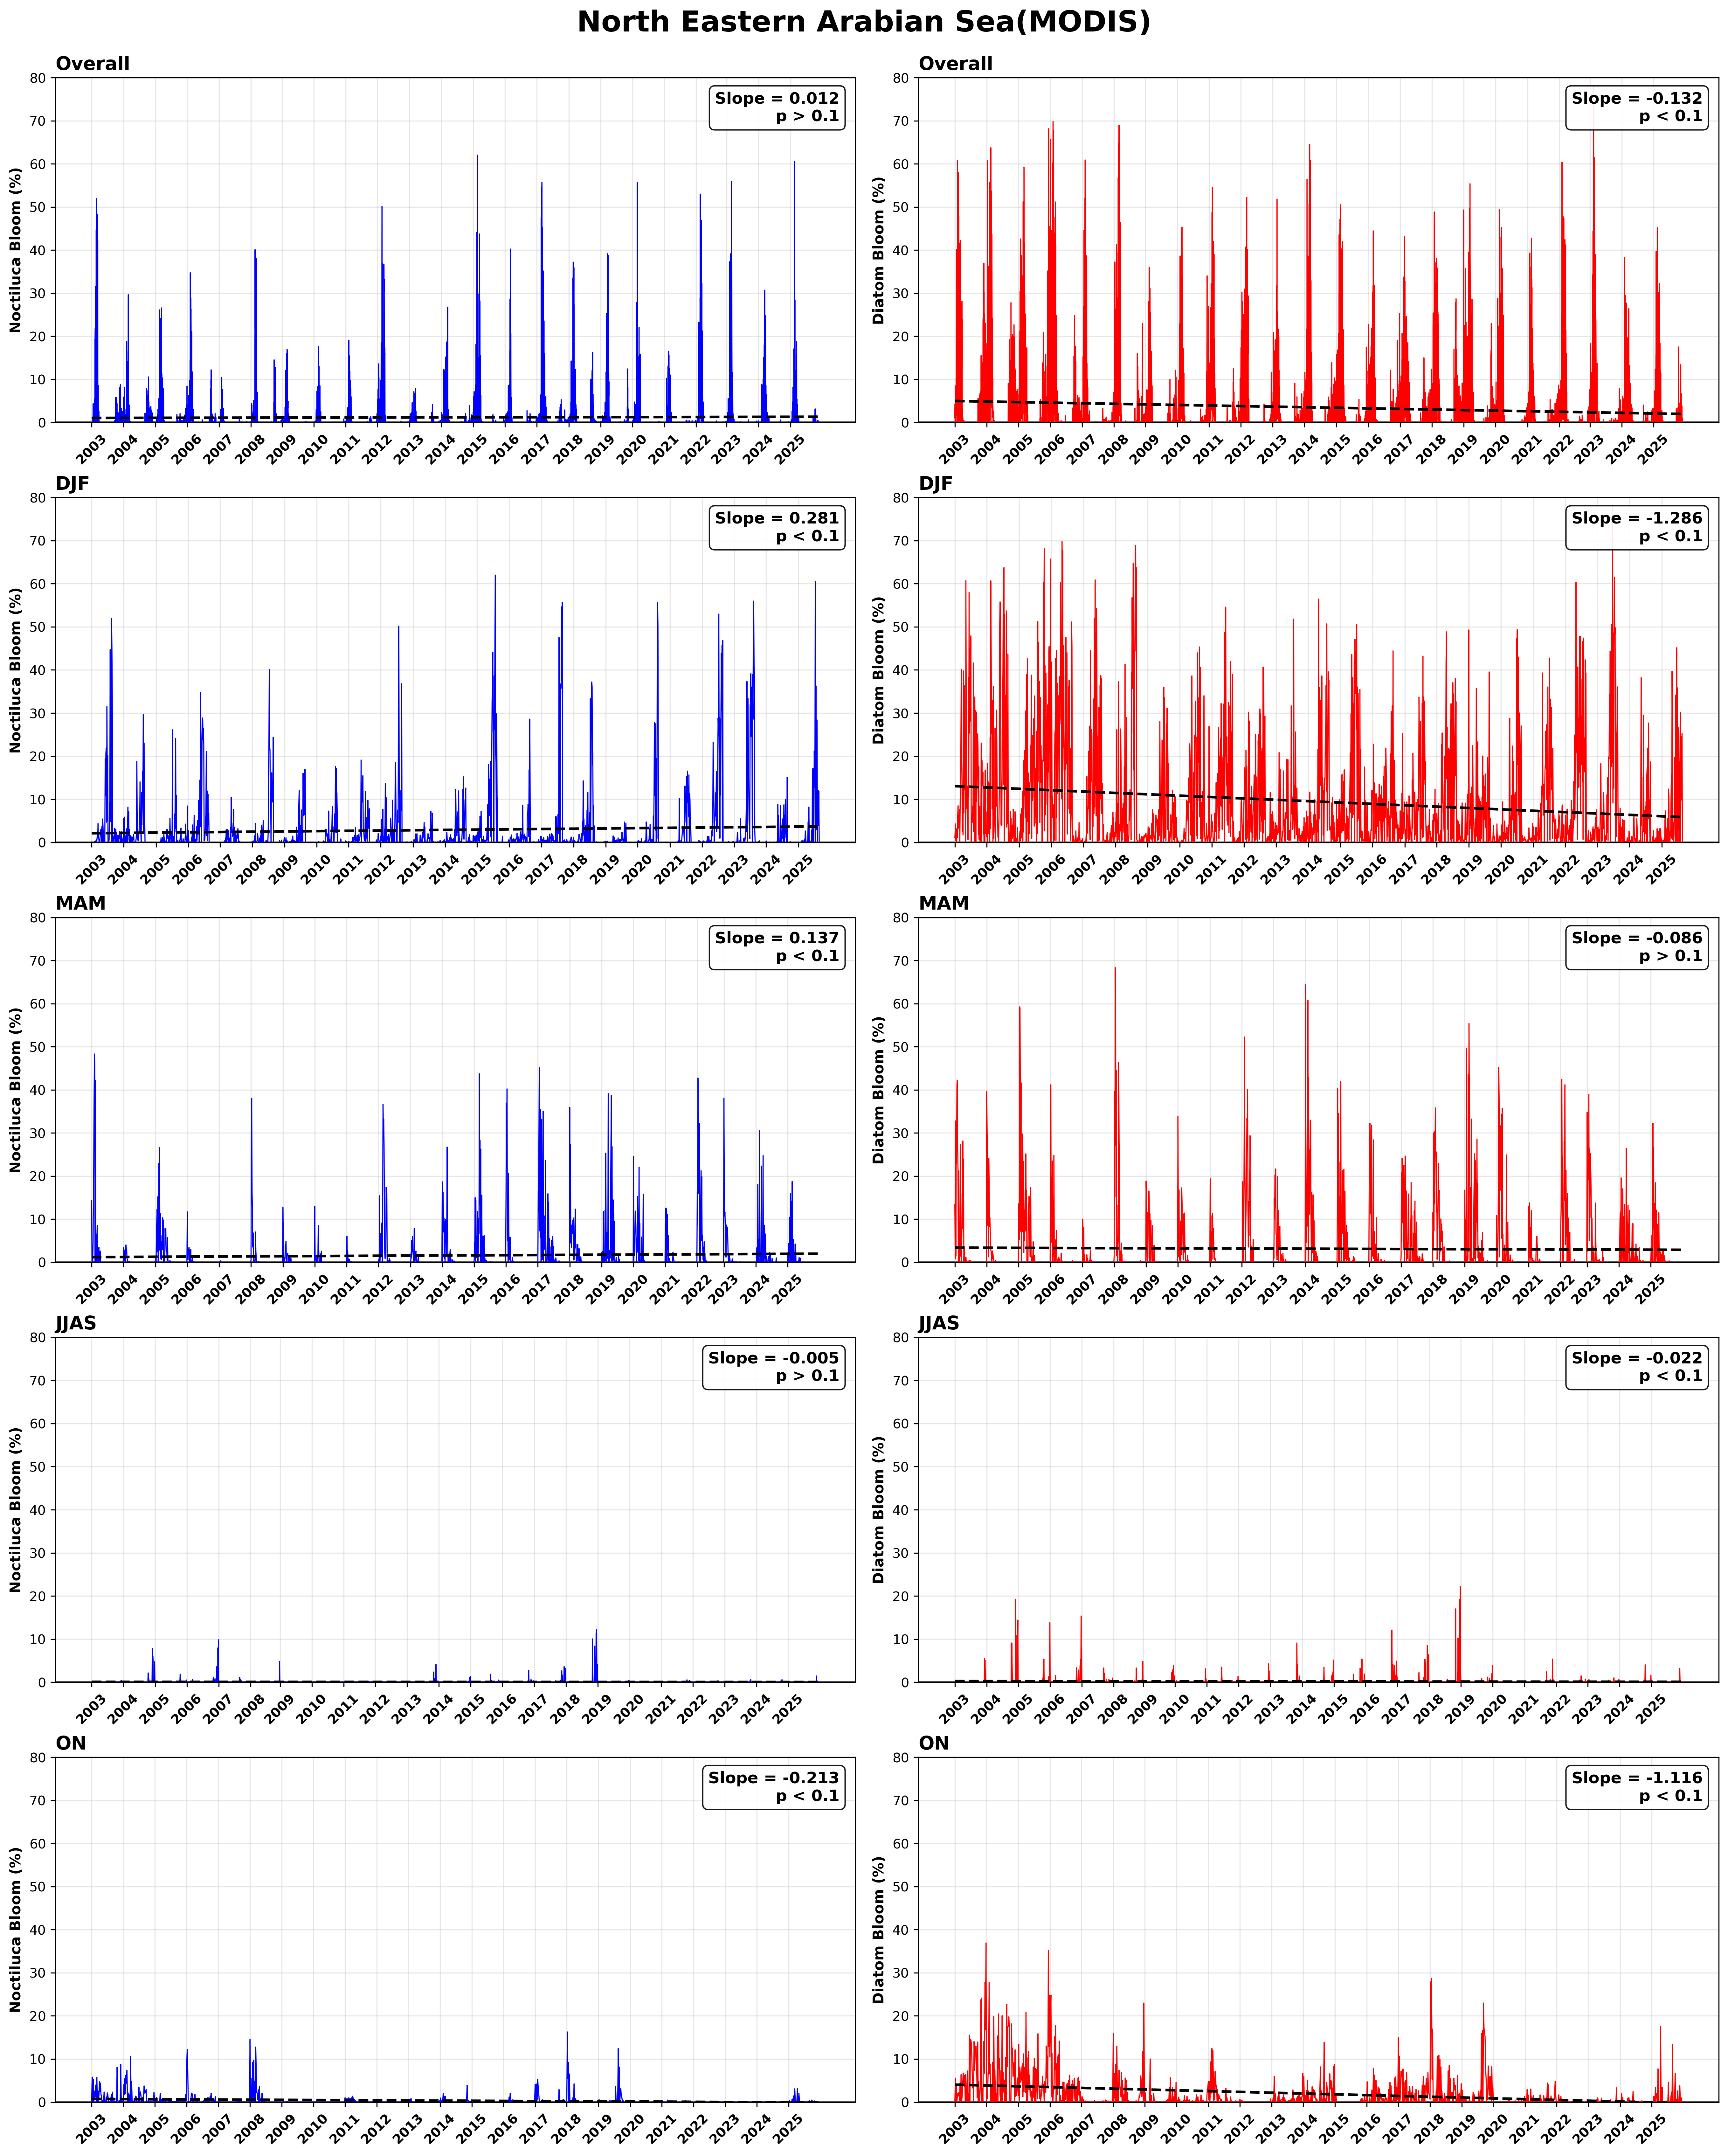

In [8]:
import matplotlib.dates as mdates

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(
    5,
    2,
    figsize=(18, 22),
    dpi=300,
    constrained_layout=True
)

fig.suptitle(
    "North Eastern Arabian Sea(MODIS)",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plot_info = [
    ("c1", "Noctiluca Bloom (%)", "blue"),
    ("c2", "Diatom Bloom (%)", "red")
]

# Find common y-limit
ymax = 0
for season in results:
    ymax = max(
        ymax,
        np.nanmax(results[season]["c1"]),
        np.nanmax(results[season]["c2"])
    )

ymax = np.ceil(ymax) + 1

# ----------------------------
# Plot each season
# ----------------------------
for i, season in enumerate(["YEAR", "DJF", "MAM", "JJAS", "ON"]):

    for j, (cls, ylabel, line_color) in enumerate(plot_info):

        ax = axes[i, j]

        # ----------------------------
        # Daily line plot (one line per season-year)
        # ----------------------------
        # ----------------------------
        # Continuous seasonal line
        # ----------------------------
        dates = pd.to_datetime(results[season]["dates"])
        bloom = results[season][cls]

        valid = ~np.isnan(bloom)

        dates = dates[valid]
        bloom = bloom[valid]

        # Sort chronologically
        order = np.argsort(dates)

        dates = dates[order]
        bloom = bloom[order]

        # Continuous x-axis
        x = np.arange(len(bloom))

        # Plot
        ax.plot(
            x,
            bloom,
            color=line_color,
            linewidth=0.8
        )

        # ----------------------------
        # Trend
        # ----------------------------
        res = linregress(x, bloom)

        trend = res.intercept + res.slope * x

        ax.plot(
            x,
            trend,
            "--",
            color="black",
            linewidth=2
        )
        slope_year = res.slope * 365.25
        
        p_text = "> 0.1" if res.pvalue > 0.1 else "< 0.1"

        ax.text(
            0.98,
            0.96,
            f"Slope = {slope_year:.3f}\np {p_text}",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="right",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="black",
                linewidth=1,
                alpha=0.9
            )
        )

        title = "Overall" if season == "YEAR" else season

        ax.set_title(
            title,
            loc="left",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_ylabel(
            ylabel,
            fontsize=11,
            fontweight="bold"
        )

        ax.grid(alpha=0.3)

        ax.set_ylim(0, ymax)

        ax.axhline(
            0,
            color="#535151",
            linewidth=1.5,
            zorder=0
        )

        # ----------------------------
        # Year tick positions
        # ----------------------------
        years_unique = np.unique(dates.year)

        tick_pos = []
        tick_lab = []

        for yr in years_unique:

            idx = np.where(dates.year == yr)[0]

            if len(idx):

                tick_pos.append(idx[0])
                tick_lab.append(str(yr))

        ax.set_xticks(tick_pos)
        ax.set_xticklabels(
            tick_lab,
            rotation=45,
            fontsize=10,
            fontweight="bold"
        )

plt.show()

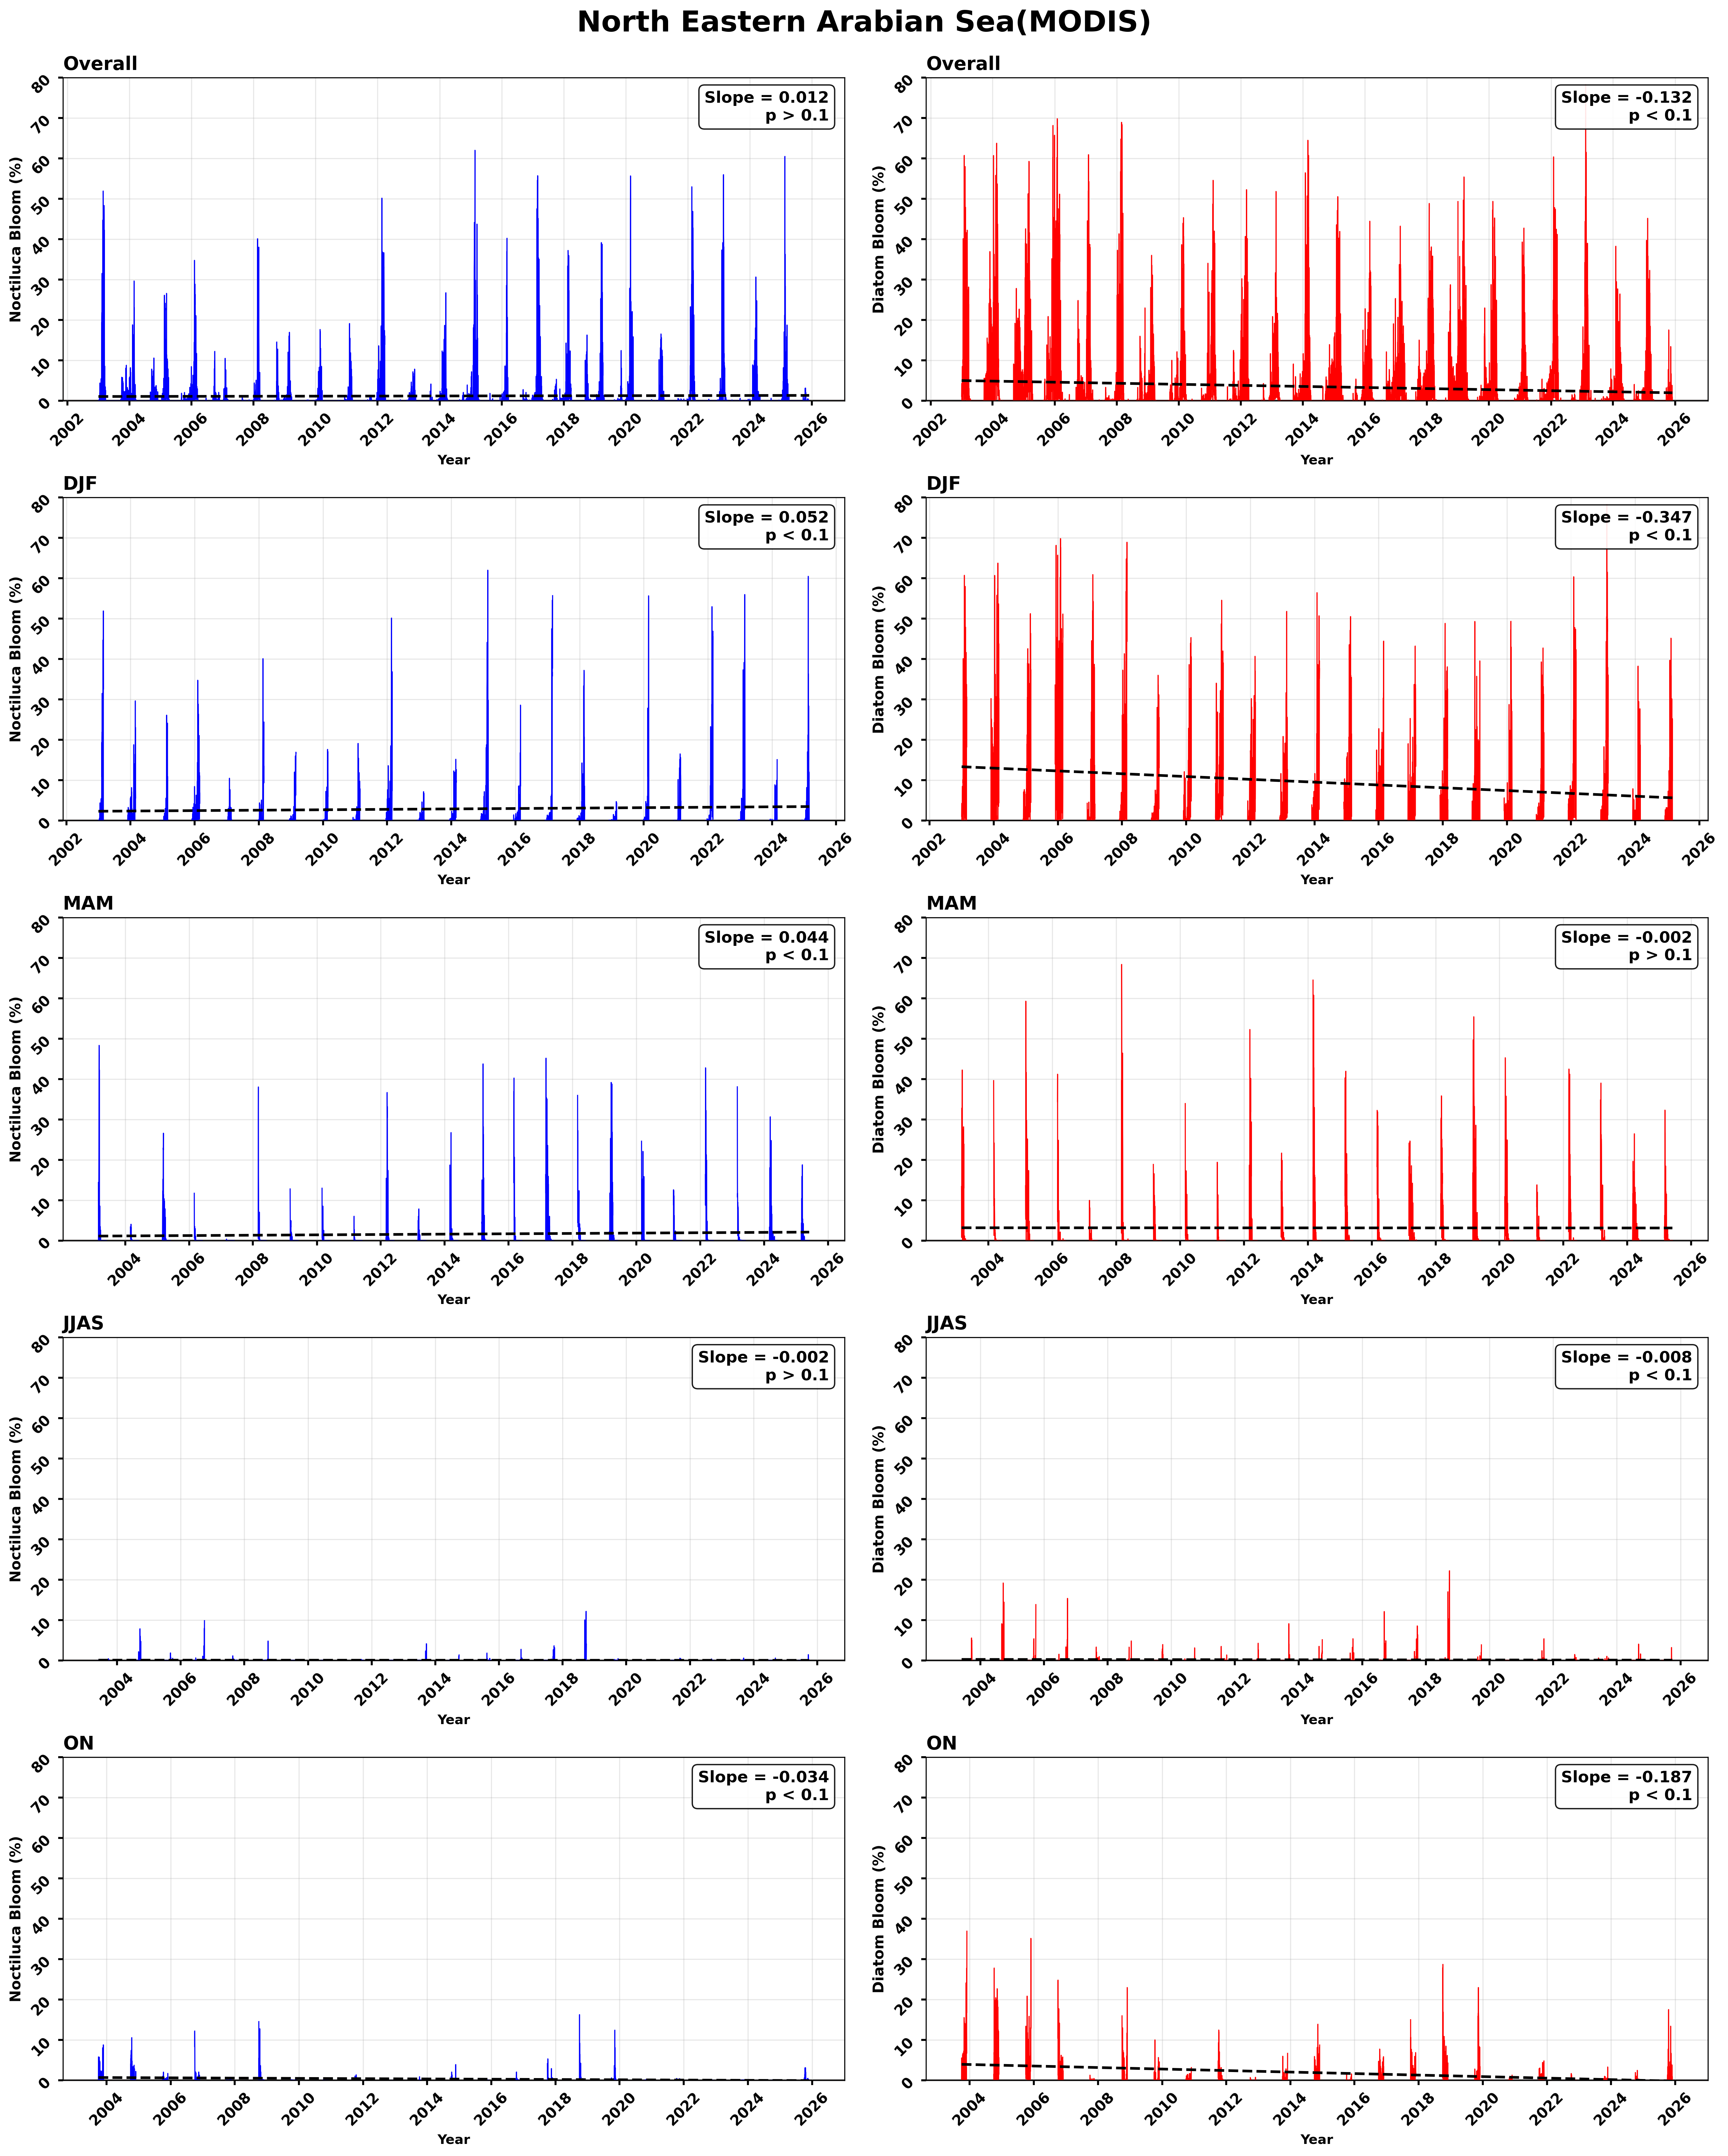

In [6]:
import matplotlib.dates as mdates

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(
    5,
    2,
    figsize=(18, 22),
    dpi=300,
    constrained_layout=True
)

fig.suptitle(
    "North Eastern Arabian Sea(MODIS)",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plot_info = [
    ("c1", "Noctiluca Bloom (%)", "blue"),
    ("c2", "Diatom Bloom (%)", "red")
]

# Find common y-limit
ymax = 0
for season in results:
    ymax = max(
        ymax,
        np.nanmax(results[season]["c1"]),
        np.nanmax(results[season]["c2"])
    )

ymax = np.ceil(ymax) + 1

# ----------------------------
# Plot each season
# ----------------------------
for i, season in enumerate(["YEAR", "DJF", "MAM", "JJAS", "ON"]):

    for j, (cls, ylabel, line_color) in enumerate(plot_info):

        ax = axes[i, j]

        # ----------------------------
        # Daily line plot (one line per season-year)
        # ----------------------------
        dates = pd.to_datetime(results[season]["dates"])
        bloom = results[season][cls]

        valid = ~np.isnan(bloom)
        dates = dates[valid]
        bloom = bloom[valid]

        df = pd.DataFrame({
            "date": dates,
            "bloom": bloom
        })

        # ----------------------------
        # Define season-year
        # ----------------------------
        if season == "DJF":

            # December belongs to next year's DJF
            df["season_year"] = np.where(
                df["date"].dt.month == 12,
                df["date"].dt.year + 1,
                df["date"].dt.year
            )

        else:

            df["season_year"] = df["date"].dt.year

        # ----------------------------
        # Plot each season-year separately
        # ----------------------------
        for _, grp in df.groupby("season_year"):

            grp = grp.sort_values("date")

            ax.plot(
                grp["date"],
                grp["bloom"],
                color=line_color,
                linewidth=0.8
            )

        # ----------------------------
        # Regression (still uses all daily values)
        # ----------------------------
        x = mdates.date2num(df["date"])

        res = linregress(x, df["bloom"])

        trend = res.intercept + res.slope * x

        order = np.argsort(x)

        ax.plot(
            df["date"].values[order],
            trend[order],
            "--",
            color="black",
            linewidth=2
        )

        # slope in % per year
        slope_year = res.slope * 365.25

        p_text = "> 0.1" if res.pvalue > 0.1 else "< 0.1"

        ax.text(
            0.98,
            0.96,
            f"Slope = {slope_year:.3f}\np {p_text}",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="right",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="black",
                linewidth=1,
                alpha=0.9
            )
        )

        title = "Overall" if season == "YEAR" else season

        ax.set_title(
            title,
            loc="left",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_ylabel(
            ylabel,
            fontsize=11,
            fontweight="bold"
        )

        ax.grid(alpha=0.3)

        ax.set_ylim(0, ymax)

        ax.axhline(
            0,
            color="#535151",
            linewidth=1.5,
            zorder=0
        )

        # ----------------------------
        # X-axis formatting
        # ----------------------------
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        ax.tick_params(
            axis="both",
            labelsize=11,
            width=1.5,
            labelrotation=45
        )

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.set_xlabel(
            "Year",
            fontsize=10,
            fontweight="bold"
        )

plt.show()